# HS In-Degree Correlation Analysis

Pearson correlations between `n_colleges_visiting` (in-degree) and all HS variables for 2019 and 2023.

**Encoding applied before correlating:**
- `school_type` → `is_public` (1 = public, 0 = private)
- `hs_charter` / `hs_magnet` → negative codes (−10, −2, −1) treated as NaN, keep 0/1
- `hs_title_i_status` → `is_title_i` binary (1 = status 1 or 2, i.e. active Title I program; 0 = otherwise; negative = NaN)
- `hs_urban_centric_locale` → `locale_city` / `locale_suburban` / `locale_town` / `locale_rural` dummies (NCES codes 11–13 = city, 21–23 = suburban, 31–33 = town, 41–43 = rural; −10 = NaN)
- `hs_highest_grade_offered`, `hs_lat`, `hs_long` excluded (not meaningful correlates of visit intensity)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## Load & Encode

In [15]:
df = pd.read_csv('../data/hs_in_degree.csv')
print(f'Loaded {len(df):,} rows — years: {sorted(df["year"].unique())}')

Loaded 40,187 rows — years: [np.int64(2019), np.int64(2023)]


In [16]:
def encode_hs(df_in):
    d = df_in.copy()

    # school_type → binary
    d['is_public'] = (d['school_type'] == 'public').astype(float)

    # charter / magnet: negative codes → NaN
    d['hs_charter'] = d['hs_charter'].where(d['hs_charter'] >= 0, np.nan)
    d['hs_magnet']  = d['hs_magnet'].where(d['hs_magnet']  >= 0, np.nan)

    # title_i: 1/2 = active Title I program → 1; 3–6 = no program → 0; negative → NaN
    d['is_title_i'] = np.where(
        d['hs_title_i_status'] < 0, np.nan,
        np.where(d['hs_title_i_status'].isin([1.0, 2.0]), 1.0, 0.0)
    )

    # locale: map NCES codes to four categories, then dummy-encode
    def locale_cat(v):
        if pd.isna(v) or v < 0:   return np.nan
        if 11 <= v <= 13:          return 'city'
        if 21 <= v <= 23:          return 'suburban'
        if 31 <= v <= 33:          return 'town'
        if 41 <= v <= 43:          return 'rural'
        return np.nan
    d['locale_cat'] = d['hs_urban_centric_locale'].apply(locale_cat)
    locale_dummies = (
        pd.get_dummies(d['locale_cat'], prefix='locale')
        .reindex(columns=['locale_city', 'locale_suburban', 'locale_town', 'locale_rural'], fill_value=False)
        .astype(float)  # cast bool→float so NaN can be assigned
    )
    locale_dummies[d['locale_cat'].isna()] = np.nan
    d = pd.concat([d, locale_dummies], axis=1)

    return d

df = encode_hs(df)
print('Encoding done.')
print(f'\nNote: hs_magnet and is_title_i are only available in 2019 (not collected in 2023).')

Encoding done.

Note: hs_magnet and is_title_i are only available in 2019 (not collected in 2023).


In [17]:
# Columns to include in the correlation matrix
corr_cols = [
    'n_colleges_visiting',
    # school characteristics
    'is_public',
    'hs_charter',
    'hs_magnet',
    'is_title_i',
    # size & resources
    'hs_enrollment',
    'hs_students_per_teacher',
    # locale
    'locale_city',
    'locale_suburban',
    'locale_town',
    'locale_rural',
    # race / ethnicity
    'hs_pct_white',
    'hs_pct_black',
    'hs_pct_hispanic',
    'hs_pct_asian',
    'hs_pct_aian',
    'hs_pct_nhpi',
    'hs_pct_two_or_more',
    # socioeconomic
    'hs_pct_free_or_reduced_price_lunch',
]

# Readable labels for plots
labels = {
    'n_colleges_visiting':              'In-Degree (# colleges visiting)',
    'is_public':                        'Is Public',
    'hs_charter':                       'Charter',
    'hs_magnet':                        'Magnet',
    'is_title_i':                       'Title I',
    'hs_enrollment':                    'Enrollment',
    'hs_students_per_teacher':          'Students per Teacher',
    'locale_city':                      'Locale: City',
    'locale_suburban':                  'Locale: Suburban',
    'locale_town':                      'Locale: Town',
    'locale_rural':                     'Locale: Rural',
    'hs_pct_white':                     '% White',
    'hs_pct_black':                     '% Black',
    'hs_pct_hispanic':                  '% Hispanic',
    'hs_pct_asian':                     '% Asian',
    'hs_pct_aian':                      '% AIAN',
    'hs_pct_nhpi':                      '% NHPI',
    'hs_pct_two_or_more':               '% Two or More',
    'hs_pct_free_or_reduced_price_lunch': '% Free/Reduced Lunch',
}

print(f'Variables in matrix: {len(corr_cols)}')

Variables in matrix: 19


## Correlations with In-Degree — 2019 and 2023

In [18]:
predictor_cols = [c for c in corr_cols if c != 'n_colleges_visiting']

corr_rows = {}
for yr in [2019, 2023]:
    sub = df[df['year'] == yr][corr_cols]
    corr_rows[yr] = sub.corrwith(sub['n_colleges_visiting']).drop('n_colleges_visiting')

corr_df = pd.DataFrame(corr_rows).rename(columns={2019: '2019', 2023: '2023'})
corr_df.index = [labels[c] for c in corr_df.index]
corr_df['avg'] = corr_df.mean(axis=1)
corr_df = corr_df.sort_values('avg', ascending=False)

print('Pearson r with In-Degree (# colleges visiting):')
print(corr_df[['2019', '2023']].round(4).to_string())

Pearson r with In-Degree (# colleges visiting):
                        2019    2023
Enrollment            0.2616  0.1501
Locale: City          0.1654  0.1489
% Asian               0.1625  0.1152
Locale: Suburban      0.1217  0.0888
% Black               0.0426  0.0524
% Hispanic            0.0262  0.0357
Magnet                0.0284  0.0203
% Two or More         0.0296 -0.0166
Students per Teacher  0.0053 -0.0013
Title I              -0.0032 -0.0107
Charter              -0.0165 -0.0022
% NHPI               -0.0137 -0.0100
% AIAN               -0.0641 -0.0509
% White              -0.0773 -0.0811
Is Public            -0.0675 -0.0920
% Free/Reduced Lunch -0.0724 -0.0906
Locale: Town         -0.1085 -0.0589
Locale: Rural        -0.1967 -0.1850


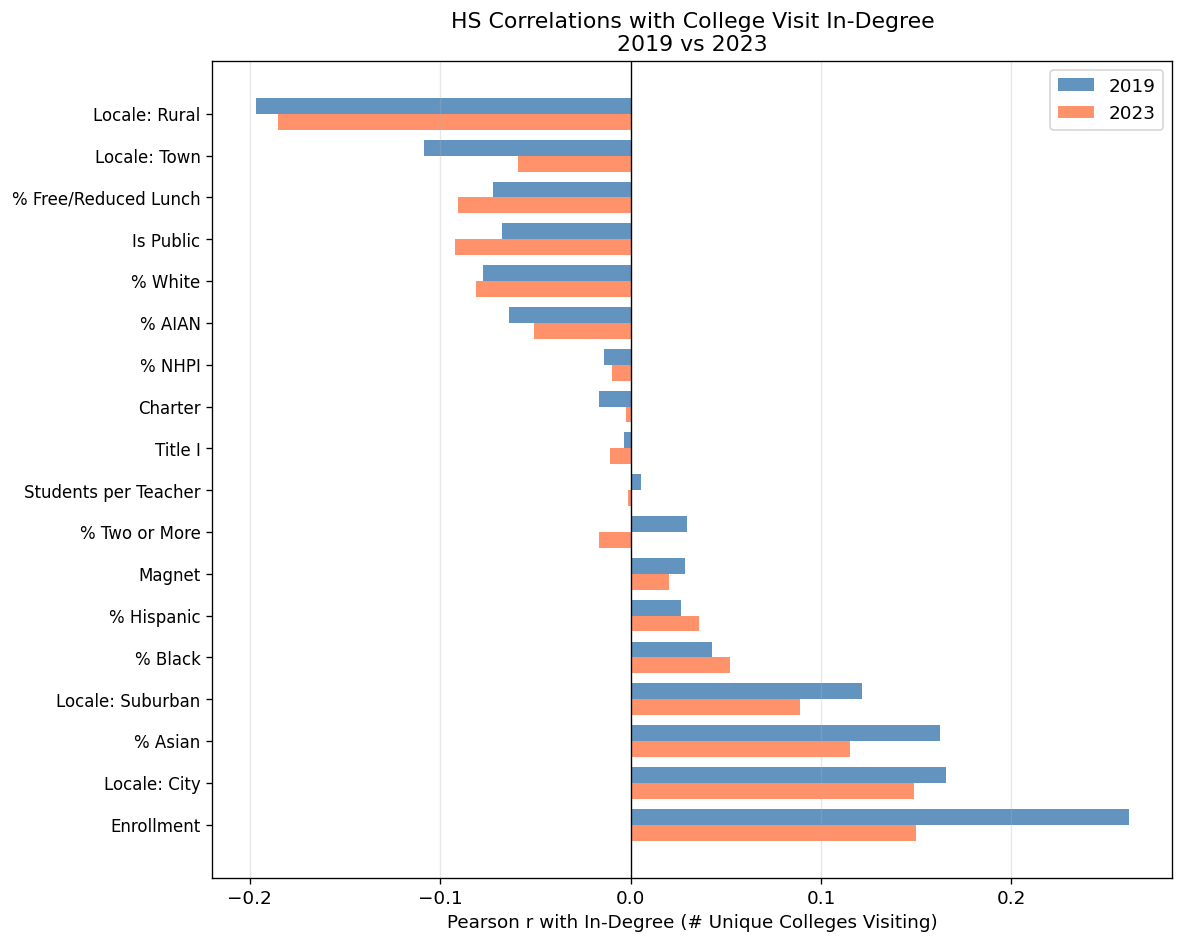

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))

x = np.arange(len(corr_df))
width = 0.38

bars_19 = ax.barh(x + width/2, corr_df['2019'], width, label='2019', color='steelblue', alpha=0.85)
bars_23 = ax.barh(x - width/2, corr_df['2023'], width, label='2023', color='coral',     alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(corr_df.index, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with In-Degree (# Unique Colleges Visiting)')
ax.set_title('HS Correlations with College Visit In-Degree\n2019 vs 2023')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/hs_indegree_corr_bars.png', bbox_inches='tight')
plt.show()

## Scatter Plots — Key Relationships

Two chart types for the strongest correlations:

- **Scatter plots (4 × 2 grid):** Top continuous predictors — Enrollment, % Asian, % Free/Reduced Lunch, % White — each shown for 2019 and 2023 with an OLS trendline and Pearson r.
- **Box plots:** Categorical predictors — Locale (city / suburban / town / rural) and School Type (public vs private) — distribution of in-degree by group for both years.

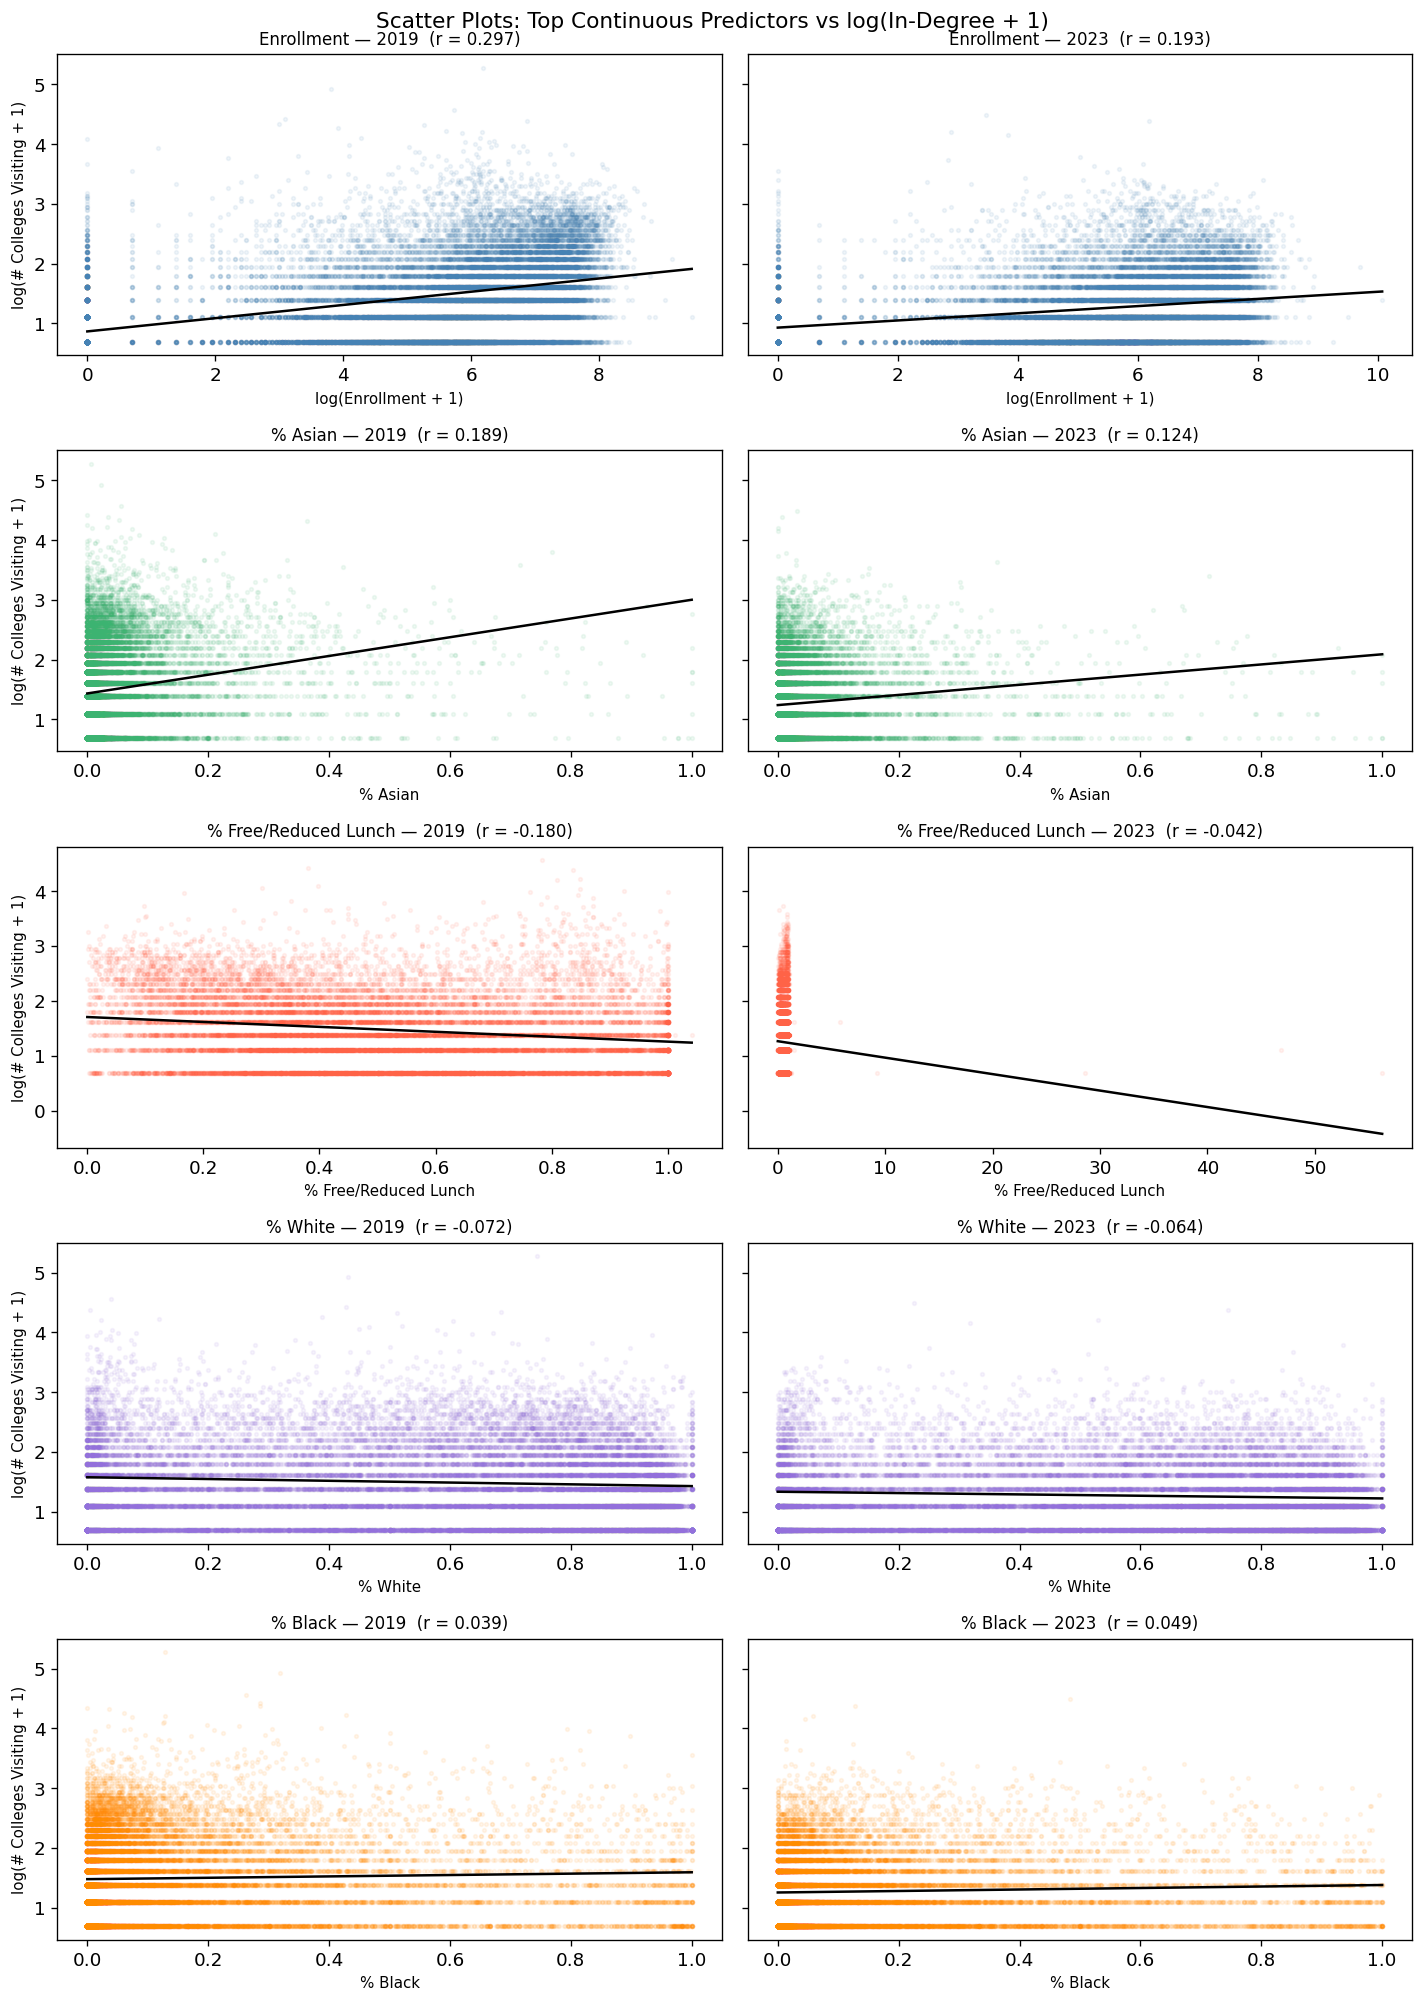

In [25]:

# Scatter plots: top continuous predictors × 2 years
# y-axis: log1p(n_colleges_visiting) everywhere (skewness 6.5 → spreads dense low-visit cluster)
# x-axis: log1p(enrollment) for enrollment panel (skewness 3.0); raw 0–1 for pct vars
# FRPL: negative sentinel values (−10 = missing) filtered before plotting
continuous_vars = [
    ('hs_enrollment',                       'Enrollment',           'steelblue',      True),
    ('hs_pct_asian',                        '% Asian',              'mediumseagreen', False),
    ('hs_pct_free_or_reduced_price_lunch',  '% Free/Reduced Lunch', 'tomato',         False),
    ('hs_pct_white',                        '% White',              'mediumpurple',   False),
    ('hs_pct_black',                        '% Black',              'darkorange',     False),
]

fig, axes = plt.subplots(5, 2, figsize=(12, 17), sharey='row')

for row, (col, lbl, color, log_x) in enumerate(continuous_vars):
    for col_idx, yr in enumerate([2019, 2023]):
        ax = axes[row, col_idx]
        sub = df[df['year'] == yr][['n_colleges_visiting', col]].dropna()
        sub = sub[sub[col] >= 0]  # drop negative sentinel values

        x_raw = sub[col].values
        x = np.log1p(x_raw) if log_x else x_raw
        y = np.log1p(sub['n_colleges_visiting'].values)

        ax.scatter(x, y, alpha=0.08, s=5, color=color, rasterized=True)
        m, b = np.polyfit(x, y, 1)
        xr = np.linspace(x.min(), x.max(), 200)
        ax.plot(xr, m * xr + b, color='black', linewidth=1.5)

        r = np.corrcoef(x, y)[0, 1]
        x_label = f'log({lbl} + 1)' if log_x else lbl
        ax.set_title(f'{lbl} — {yr}  (r = {r:.3f})', fontsize=10)
        ax.set_xlabel(x_label, fontsize=9)
        if col_idx == 0:
            ax.set_ylabel('log(# Colleges Visiting + 1)', fontsize=9)

fig.suptitle('Scatter Plots: Top Continuous Predictors vs log(In-Degree + 1)', fontsize=13)
plt.tight_layout()
plt.savefig('../data/hs_indegree_scatter_continuous.png', bbox_inches='tight')
plt.show()


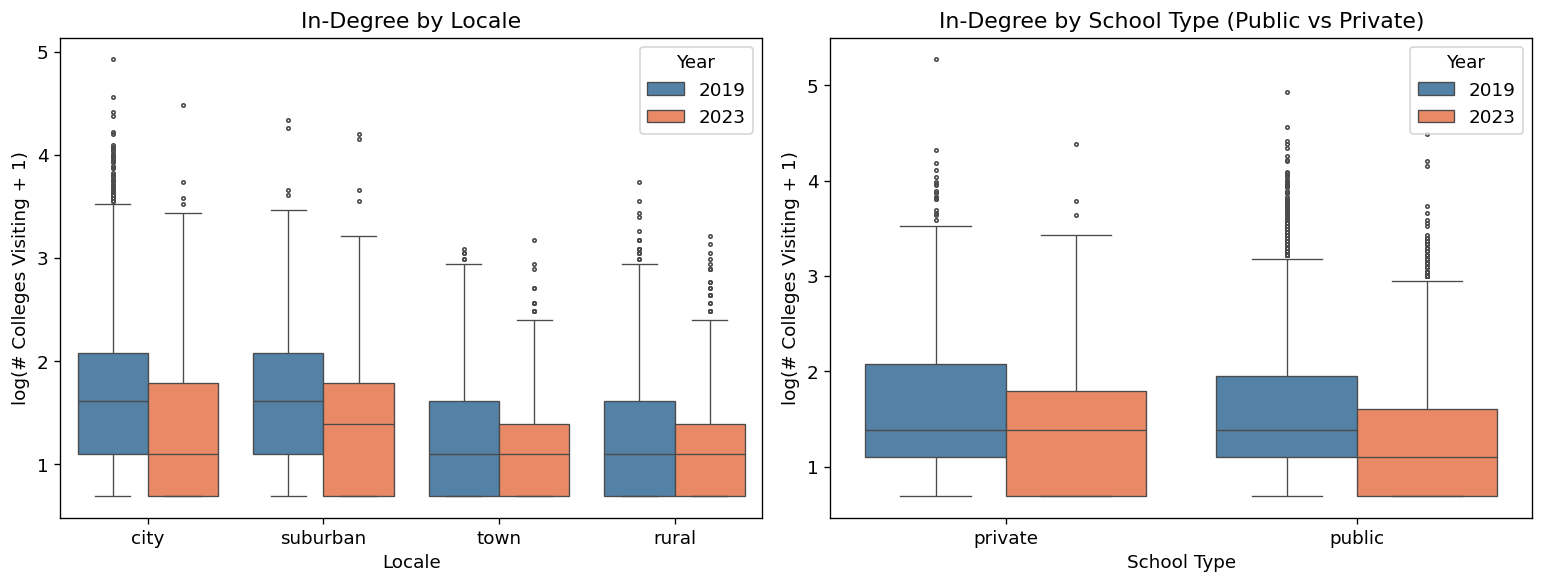

In [24]:

# Box plots: locale and school type — log-scaled in-degree
# log1p keeps the box body readable instead of squashed near zero
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

locale_order = ['city', 'suburban', 'town', 'rural']
plot_locale = df[df['locale_cat'].notna()].copy()
plot_locale['log_indegree'] = np.log1p(plot_locale['n_colleges_visiting'])
plot_locale['year'] = plot_locale['year'].astype(str)
sns.boxplot(
    data=plot_locale, x='locale_cat', y='log_indegree', hue='year',
    order=locale_order, palette={'2019': 'steelblue', '2023': 'coral'},
    fliersize=2, linewidth=0.8, ax=ax1,
)
ax1.set_xlabel('Locale')
ax1.set_ylabel('log(# Colleges Visiting + 1)')
ax1.set_title('In-Degree by Locale')
ax1.legend(title='Year')

plot_type = df[df['school_type'].notna()].copy()
plot_type['log_indegree'] = np.log1p(plot_type['n_colleges_visiting'])
plot_type['year'] = plot_type['year'].astype(str)
sns.boxplot(
    data=plot_type, x='school_type', y='log_indegree', hue='year',
    palette={'2019': 'steelblue', '2023': 'coral'},
    fliersize=2, linewidth=0.8, ax=ax2,
)
ax2.set_xlabel('School Type')
ax2.set_ylabel('log(# Colleges Visiting + 1)')
ax2.set_title('In-Degree by School Type (Public vs Private)')
ax2.legend(title='Year')

plt.tight_layout()
plt.savefig('../data/hs_indegree_boxplots_categorical.png', bbox_inches='tight')
plt.show()


## Save Correlation Table

In [20]:
corr_df[['2019', '2023']].to_csv('../data/hs_indegree_corr.csv')
print(f'Saved ../data/hs_indegree_corr.csv')

Saved ../data/hs_indegree_corr.csv
